[2026-07-10 06:41:28] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-10 06:41:32] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-10 06:41:32] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-10 06:41:34] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-10 06:41:34] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-10 06:41:34] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-10 06:41:34] [info     ] ========== 数据检查 ==========
[2026-07-10 06:41:34] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg

时段,IC
2024-01-15~2024-02-08,0.0104
2024-09-24~2024-10-08,0.0033

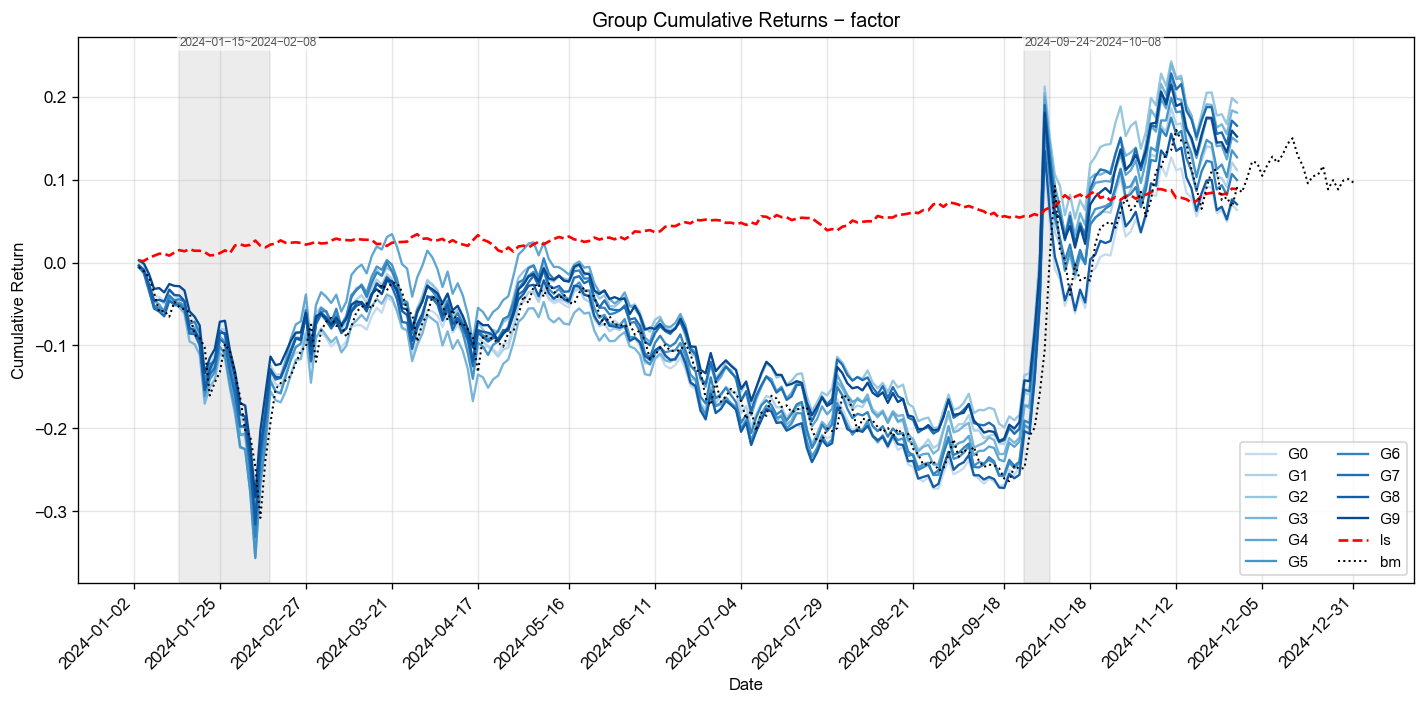
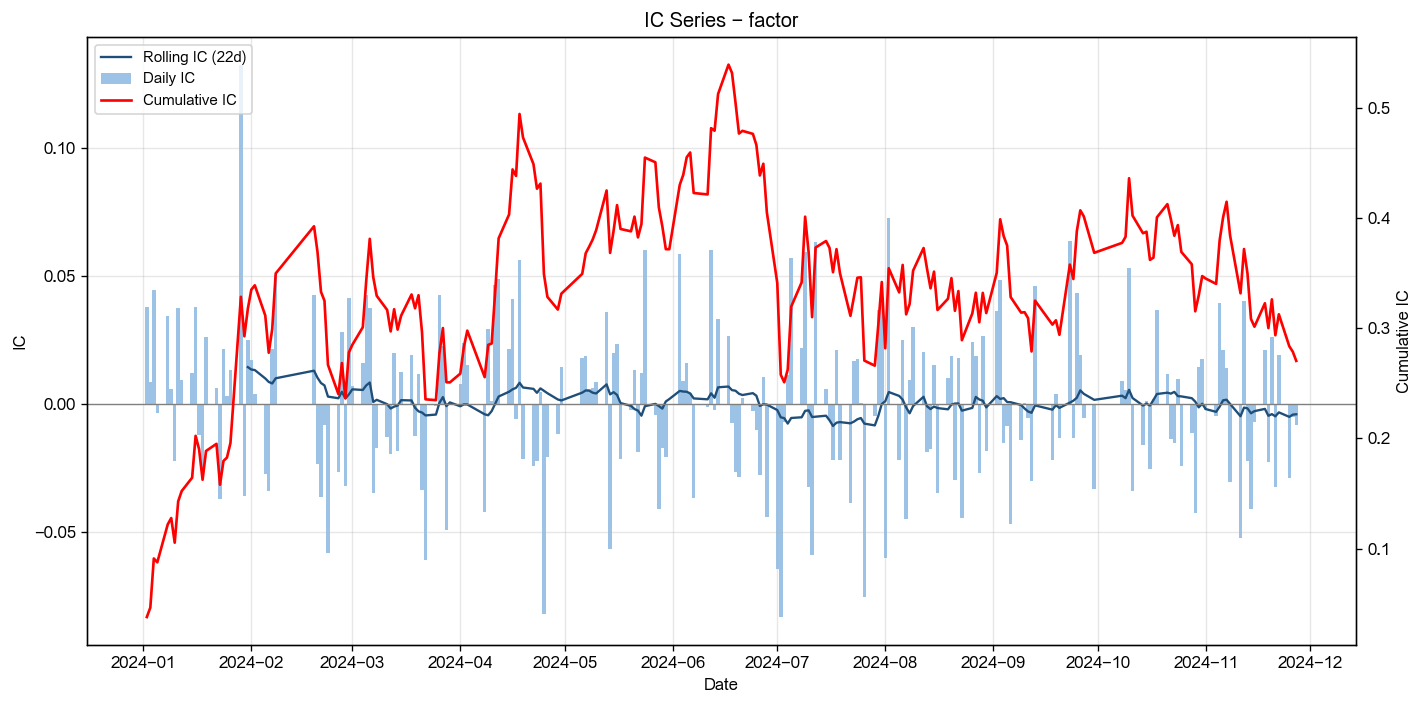
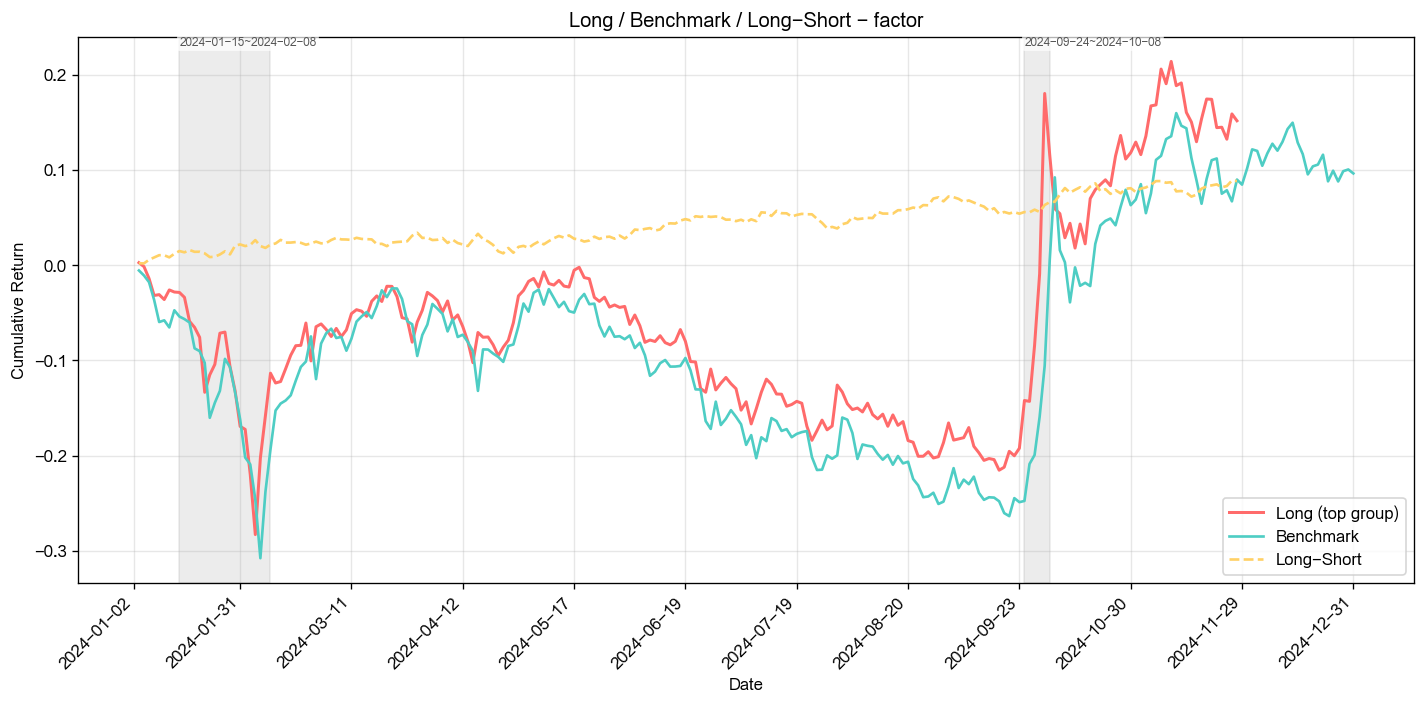
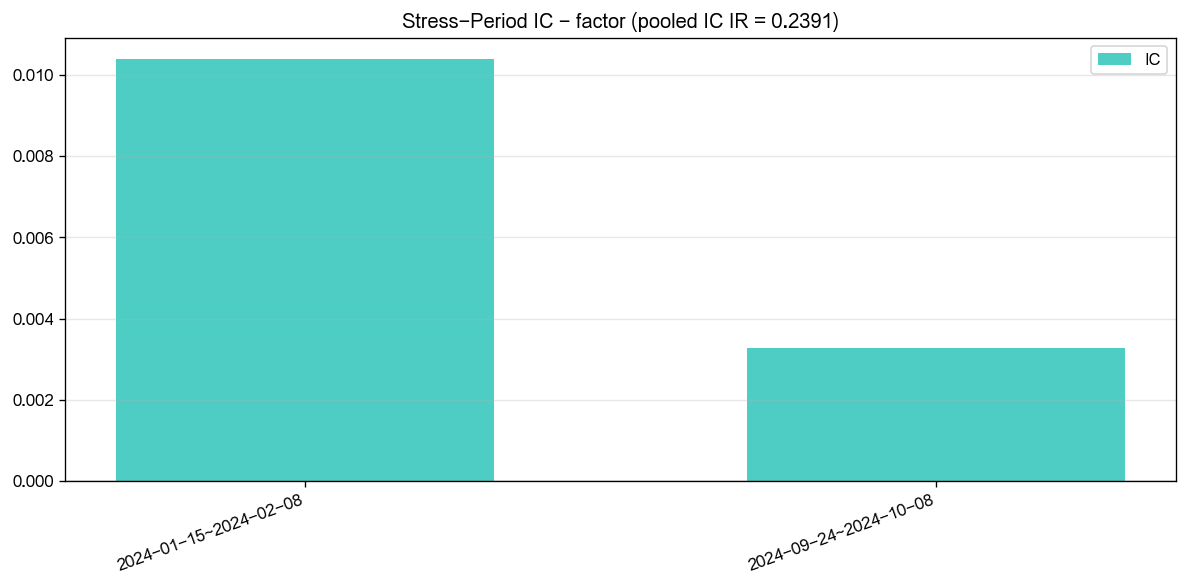
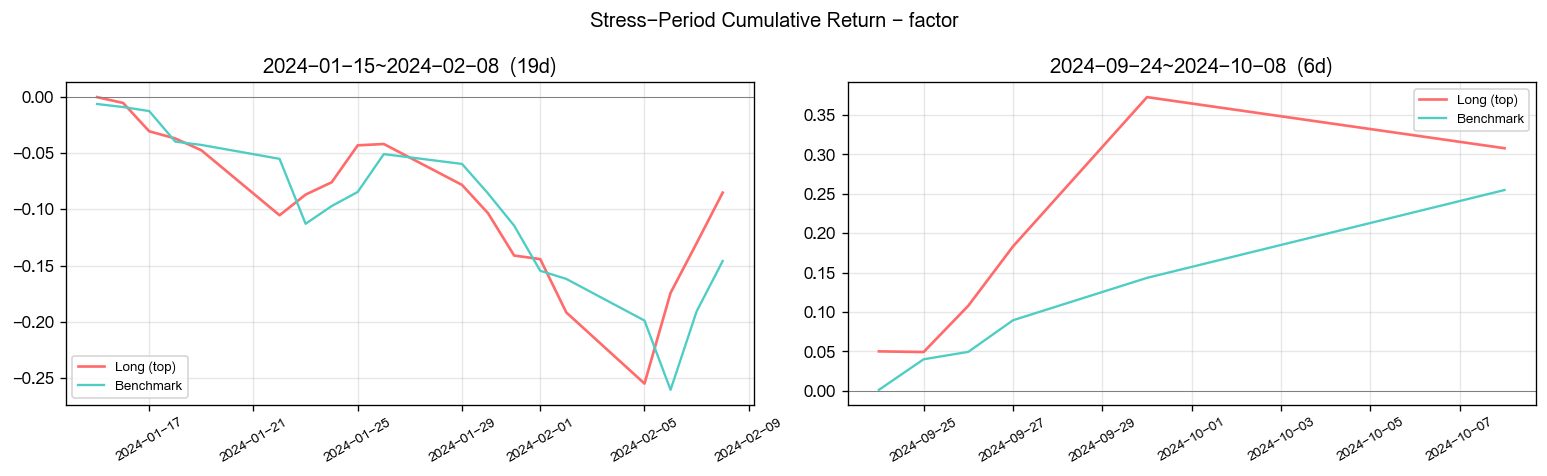

[2026-07-10 06:43:09] [info     ] ========== 因子池回归 ==========
[2026-07-10 06:43:10] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-10 06:43:10] [info     ] 获取收益率数据, 耗时: 1.0013 秒
[2026-07-10 06:43:11] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.5548 秒
[2026-07-10 06:43:11] [info     ] 统计 回归结果, 耗时: 0.0062 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9889,0.0449,0.0226,1.0000
2,gross_profit_rate_ttm,1.5453,0.0071,0.0046,1.0000
3,amount,1.5374,0.0182,0.0118,0.8000
4,net_profit_rate_ttm,1.5134,0.0064,0.0042,1.0000
5,netflow_amount_main,1.4884,0.0249,0.0167,1.0000
6,netflow_amount_rate_main,1.4659,0.0102,0.0070,1.0000
7,bias_20,1.4118,0.0298,0.0211,0.9000
8,cci_14,1.4099,0.0343,0.0244,1.0000
9,pb,1.3780,0.0096,0.0070,1.0000
10,debt_to_asset_lf,1.3411,0.0089,0.0066,0.9000

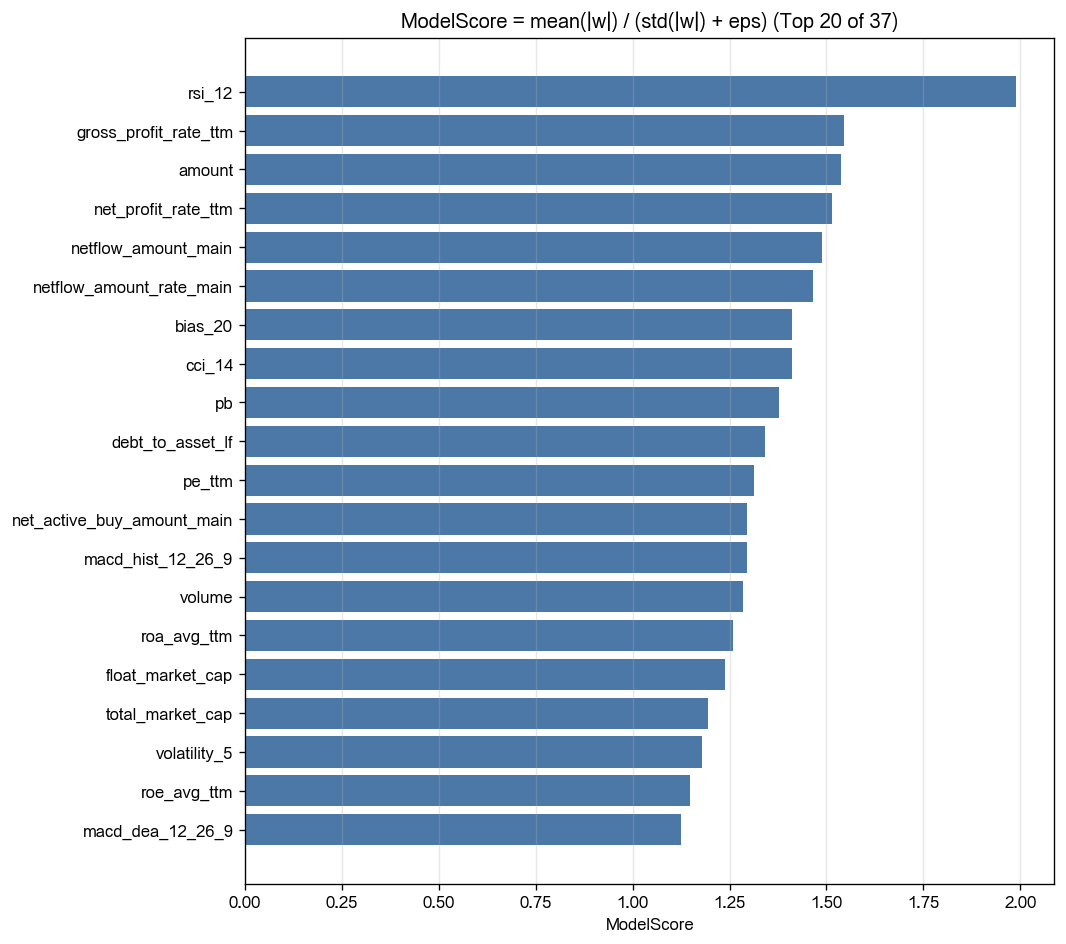
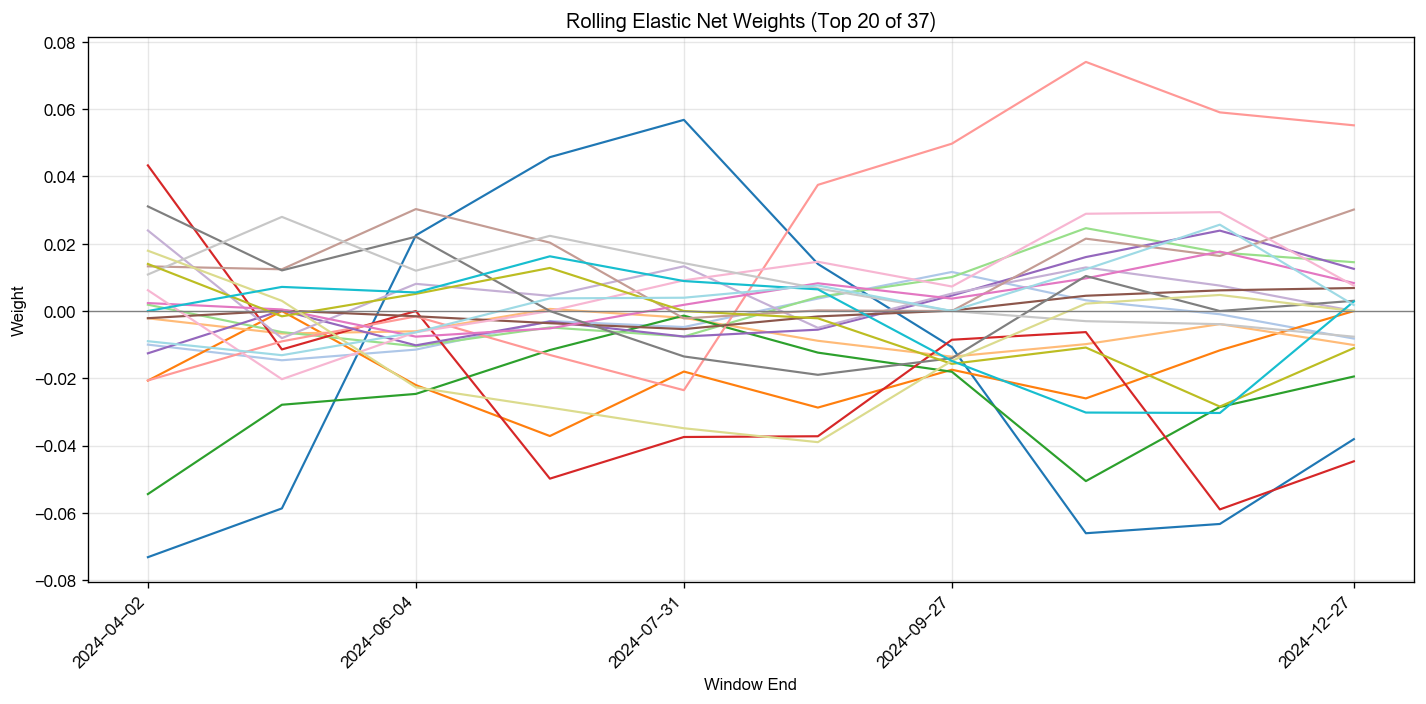
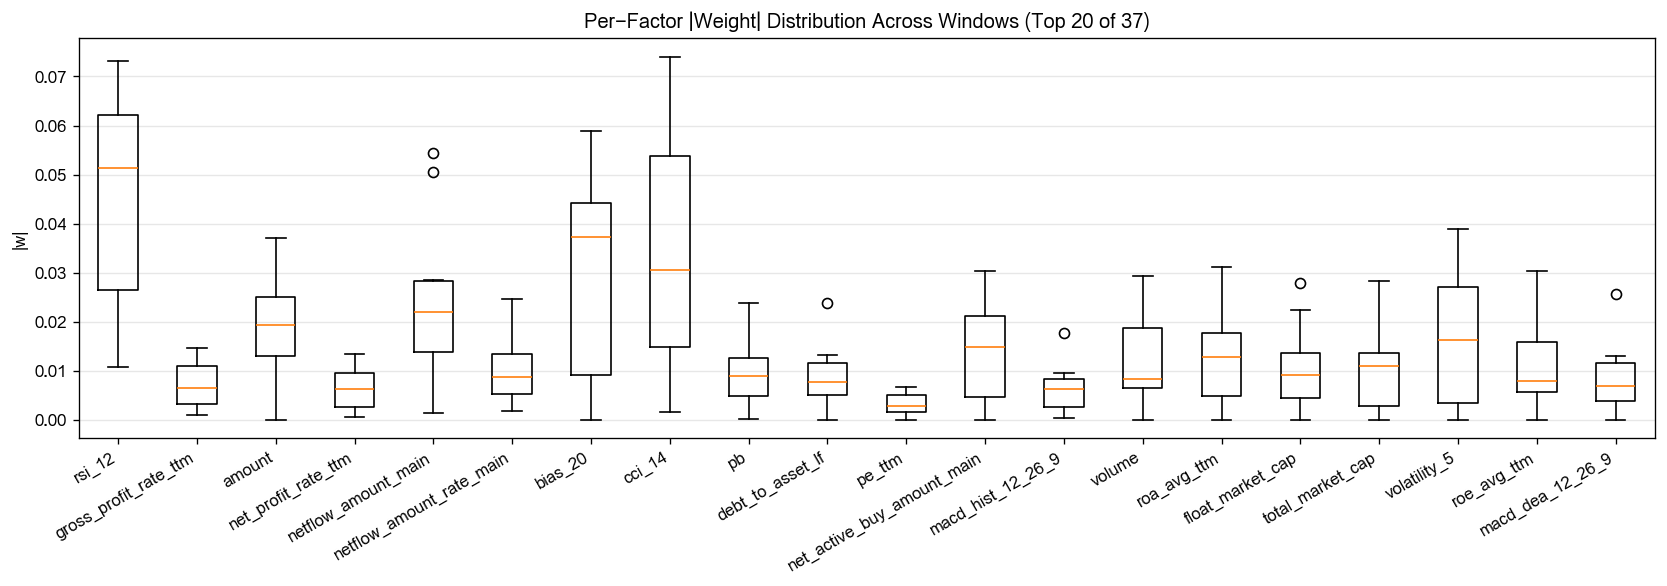
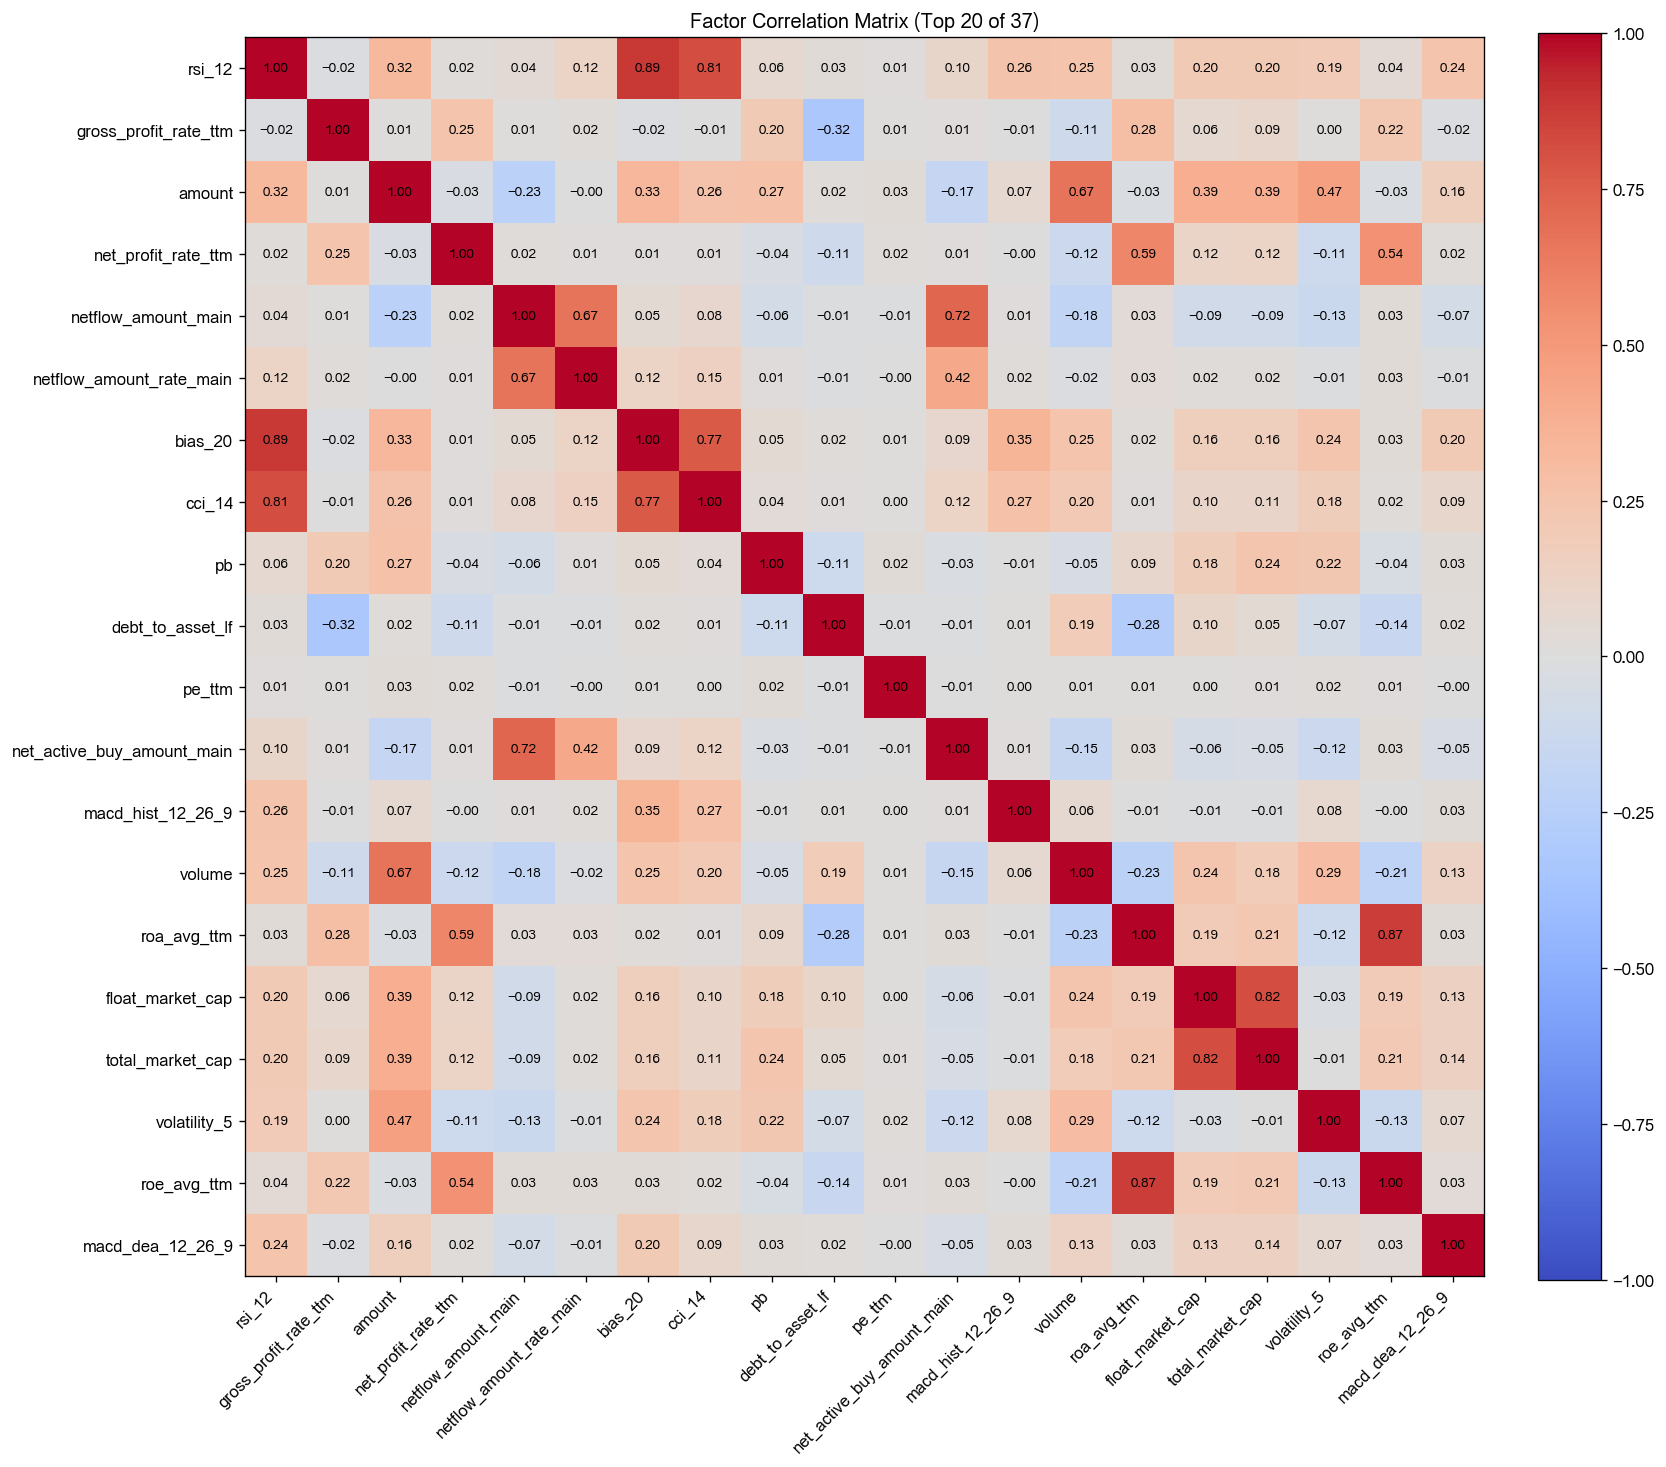

[2026-07-10 06:43:14] [warning  ] 返回的Outputs实例(size=35178162) 大于 64K, 将不会被缓存
[2026-07-10 06:43:14] [info     ] bigalpha_eval.v4 运行完成 [99.657s].


In [21]:
def main(datasources, start_date, end_date):
    import dai
    import pandas as pd
    import numpy as np
    from sklearn.linear_model import LinearRegression          # ===新增===

    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]}
    ).df()



    #获取财务数据(这里向前看一年的数据)
    df_latest = dai.query(
        "SELECT report_date ,instrument,category,fcff FROM bigalpha_2026_financial WHERE category = 'ttm'",
        filters={"date": ["2023-01-01", end_date],
                 "report_date":["2023-01-01", end_date]}
    ).df()
    df_latest = df_latest.sort_values(['instrument', 'report_date'])
    df_latest = df_latest.dropna()
    df_unique = df_latest.drop_duplicates(subset=['instrument', 'report_date'], keep='last')
    df_unique = df_unique.sort_values(['instrument', 'report_date']).reset_index(drop=True)

    df_unique['report_date'] = pd.to_datetime(df_unique['report_date'])

    #几乎半年发布的财报，进行数据的日频填充
    def fill_daily(group):
        group = group.set_index('report_date').sort_index()
        full_range = pd.date_range(start=group.index.min(), end=end_date, freq='D')
        group_filled = group.reindex(full_range, method='ffill')
        group_2024 = group_filled.loc[start_date:end_date].copy()
        group_2024 = group_2024.reset_index().rename(columns={'index': 'date'})
        return group_2024[['date', 'instrument', 'category', 'fcff']]

    df_daily = df_unique.groupby('instrument', group_keys=False).apply(fill_daily).reset_index(drop=True)


    #把fcff数据（）进行截面百分位标准化到[-1, 1]
    def rank_to_11(group, col):
        pct = group[col].rank(pct=True, method='average')
        return pct * 2 - 1

    df_daily['fcff'] = df_daily.groupby('date').apply(
        lambda g: rank_to_11(g, 'fcff')
    ).reset_index(level=0, drop=True)

    #整理最终fcff因子表 
    df = df_daily[['date', 'instrument', 'fcff']].copy()
    df = df.sort_values(['date', 'instrument']).reset_index(drop=True)

    #与股票池合并（原逻辑）
    fcff = pd.merge(
        df_daily[['date', 'instrument', 'fcff']],
        stk_pool[['date', 'instrument']],
        on=['date', 'instrument'],
        how='inner'
    ).sort_values(['date', 'instrument']).reset_index(drop=True)

    # print(fcff)



    size = dai.query("SELECT date, instrument ,weights FROM bigalpha_2026_exposure", filters={"date": [start_date, end_date]}).df()
    size = size.sort_values(['weights']).reset_index(drop=True)

    #市值权重因子表
    size = pd.merge(
        stk_pool[['date', 'instrument']],
        size[['date', 'instrument', 'weights']],
        on=['date', 'instrument'],
        how='right'
    ).sort_values(['date', 'instrument']).reset_index(drop=True)




    #统一日期格式
    fcff['date'] = pd.to_datetime(fcff['date'])
    size['date'] = pd.to_datetime(size['date'])
    # print(size)

    #合并两个因子，取交集（只保留两者都有的 date+instrument）
    merged = pd.merge(
        fcff[['date', 'instrument', 'fcff']],
        size[['date', 'instrument', 'weights']],
        on=['date', 'instrument'],
        how='inner'
    )

    #因子合成：用来选老登股（高现金流高市值的）
    merged['composite'] = (merged['fcff']*(merged['weights'])) 
    


    #最终因子表
    final_factor = merged[['date', 'instrument', 'composite']].rename(
        columns={'composite': 'factor'}
    )


    # print(final_factor)
    
    return final_factor

if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # 本地自测时自行构造数据源映射（评测时由平台注入，逻辑名固定为 "bar1m"/"financial"）
    datasources = {'financial': 'bigalpha_2026_financial',}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    # 计算因子
    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取平台因子库用于回归评估，您可以换成自己的因子库
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    # 评估系统：
    # process_pools=False 表示不对因子库再做预处理（bigalpha_2026_factorlib 已处理过）
    # show=True 表示画出评估图表
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )